<a href="https://colab.research.google.com/github/junnishiye/SERS_2semestre_checkpoint_2/blob/main/checkpoint2_aulas6_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Aulas 6 e 7: classificação e regressão

**Integrante:** João Vitor Jun Nishiye de Sousa — RM 572079.

As células da Aula 6 foram preservadas literalmente e executadas antes da Aula 7. A Aula 7 reutiliza o DataFrame `dados` carregado no início.


##modelo de classificação

treinar um modelo preditivo de classificação, utilizando o algoritimo: regressão logistica (logistic regression do sklearn) para prever se a rede eletrica esta estavel ou instavel com base nos atributos fornecidos na fonte

fonte:https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data

In [ ]:
#preparação do ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#algoritimo de regressão logistica
from sklearn.linear_model import LogisticRegression
#funcao que permite separação de treino e teste
from sklearn.model_selection import train_test_split
# metricas para classificação
from sklearn.metrics import accuracy_score

#matrix de confusão
from sklearn.metrics import confusion_matrix


In [ ]:
# carregar dados e criar dataframe
dados = pd.read_csv('https://raw.githubusercontent.com/junnishiye/SERS_2semestre_checkpoint_2/refs/heads/main/Data_for_UCI_named.csv')
dados.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [ ]:
#inspeção basica
dados.shape

(10000, 14)

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [ ]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [ ]:
#estatisticas descritivas
#somente atributos categoricos
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [ ]:
# quais as casses que temos no atributo 'stabf'
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [ ]:
#quantos registros temos em cada classe em stabf
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [ ]:
#dados de entreda X ---> features ---> dataframe
# Variaveis independentes
X = dados.drop(['stab','stabf'],axis = 1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [ ]:
dados['stabf'] = dados['stabf'].replace ({"unstable":"instavel", "stable":"estavel"})
dados['stabf'].value_counts()

,count
stabf,
instavel,6380
estavel,3620


In [ ]:
#dados de saida y ---> target ----> o que vamos prever
#variavel dependente
y = dados['stabf']
y

,stabf
0,instavel
1,estavel
2,instavel
3,instavel
4,instavel
...,...
9995,instavel
9996,estavel
9997,estavel
9998,instavel


In [ ]:
# Separação de dados para treino e para teste (train_test_split)
# X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X.shape[0]

10000

In [ ]:
X_train.shape[0]

7000

In [ ]:
X_test.shape[0]

3000

In [ ]:
# Instanciando o modelo com base no algoritmo Logistic Regression
modelo = LogisticRegression()

In [ ]:
# Treinando o modelo
modelo.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_test[:50]

,stabf
6252,instavel
4684,instavel
1731,instavel
4742,estavel
4521,estavel
6340,instavel
576,estavel
5202,instavel
6363,instavel
439,estavel


In [ ]:
# Gerando as probabilidades
probabilidades = modelo.predict_proba(X_test)
probabilidades[:50]

array([[0.04832458, 0.95167542],
       [0.06765984, 0.93234016],
       [0.32851224, 0.67148776],
       [0.9774269 , 0.0225731 ],
       [0.63944896, 0.36055104],
       [0.57932851, 0.42067149],
       [0.75220971, 0.24779029],
       [0.0253573 , 0.9746427 ],
       [0.0491907 , 0.9508093 ],
       [0.75081851, 0.24918149],
       [0.0574757 , 0.9425243 ],
       [0.45204514, 0.54795486],
       [0.56012373, 0.43987627],
       [0.2390839 , 0.7609161 ],
       [0.01632351, 0.98367649],
       [0.25307423, 0.74692577],
       [0.44524977, 0.55475023],
       [0.1910339 , 0.8089661 ],
       [0.43188331, 0.56811669],
       [0.33936356, 0.66063644],
       [0.08175104, 0.91824896],
       [0.12786239, 0.87213761],
       [0.19940876, 0.80059124],
       [0.76364784, 0.23635216],
       [0.32962162, 0.67037838],
       [0.30896806, 0.69103194],
       [0.62552247, 0.37447753],
       [0.46526131, 0.53473869],
       [0.70576222, 0.29423778],
       [0.9237145 , 0.0762855 ],
       [0.

In [ ]:

# Gerando as previsões
y_predict = modelo.predict(X_test)
y_predict[:50]

array(['instavel', 'instavel', 'instavel', 'estavel', 'estavel',
       'estavel', 'estavel', 'instavel', 'instavel', 'estavel',
       'instavel', 'instavel', 'estavel', 'instavel', 'instavel',
       'instavel', 'instavel', 'instavel', 'instavel', 'instavel',
       'instavel', 'instavel', 'instavel', 'estavel', 'instavel',
       'instavel', 'estavel', 'instavel', 'estavel', 'estavel',
       'instavel', 'estavel', 'estavel', 'instavel', 'instavel',
       'instavel', 'estavel', 'estavel', 'instavel', 'instavel',
       'instavel', 'instavel', 'instavel', 'estavel', 'estavel',
       'instavel', 'estavel', 'instavel', 'estavel', 'estavel'],
      dtype=object)

In [ ]:
# Acurácia do modelo
acuracia = 100 * accuracy_score(y_test, y_predict)
print(f'A acurácia do modelo é de {acuracia:.2f}%')

A acurácia do modelo é de 80.77%


In [ ]:

# Gerar matriz de confusão com matplotlib e heatmap
matriz_confusao = confusion_matrix(y_test, y_predict)
matriz_confusao

array([[ 748,  313],
       [ 264, 1675]])

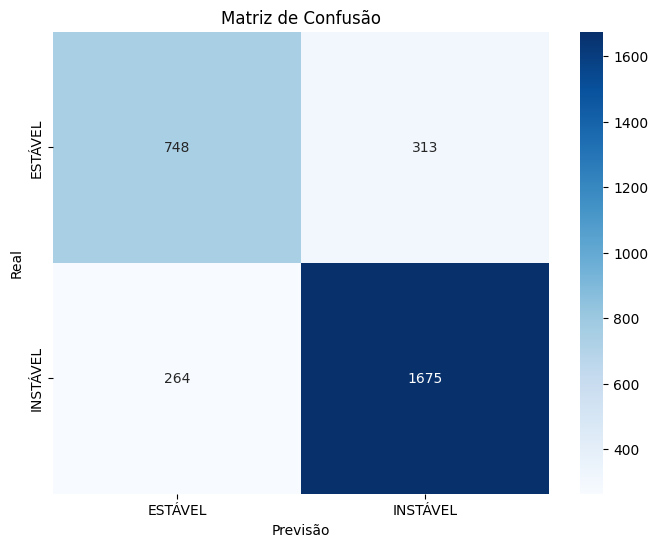

In [ ]:

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ESTÁVEL', 'INSTÁVEL'], yticklabels=['ESTÁVEL', 'INSTÁVEL'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# Aula 7 – Regressão linear e estabilidade da rede elétrica

A partir do mesmo dataset da Aula 6, prevemos `stab` com dois modelos de regressão e comparamos R², MAE e MSE.


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [ ]:
# Bibliotecas da regressão linear e métricas
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 2. Carregamento e análise inicial do dataset

Os dados já foram carregados na Aula 6. Aqui, `df` é uma cópia de `dados`.


In [ ]:
# Reutiliza os dados carregados na Aula 6, sem alterar a classificação original.
df = dados.copy()
display(df.head())
print(f'Quantidade de linhas: {df.shape[0]}')
print(f'Quantidade de colunas: {df.shape[1]}')
print('Colunas e tipos:')
print(df.dtypes)
print('Valores ausentes por coluna:')
print(df.isna().sum())
display(df.describe())


Quantidade de linhas: 10000
Quantidade de colunas: 14
Colunas e tipos:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object
Valores ausentes por coluna:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,instavel
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,estavel
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,instavel
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,instavel
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,instavel


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


### Registro da análise inicial

**Quantidade de linhas:** 10.000.  
**Quantidade de colunas:** 14.  
**Existem valores ausentes?** Não.  
**Observações importantes:** A coluna `stab` é numérica; `stabf` é a classe categórica prevista na Aula 6. Ela não entra nas correlações numéricas.


## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [ ]:
# Variável numérica que será prevista pelos dois modelos de regressão.
y = df['stab']
display(y.head())


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
tau1,1.000000,0.015586,-0.005970,-0.017265,0.027183,-0.015485,-0.015924,-0.015807,0.010521,0.015350,-0.001279,0.005494,0.275761
tau2,0.015586,1.000000,0.014273,-0.001965,-0.004769,0.006573,0.007673,-0.005963,-0.001742,0.015383,0.016508,-0.011764,0.290975
tau3,-0.005970,0.014273,1.000000,0.004354,0.016953,-0.003134,-0.008780,-0.017531,-0.011605,0.007671,0.014702,-0.011497,0.280700
tau4,-0.017265,-0.001965,0.004354,1.000000,-0.003173,0.010553,0.006169,-0.011211,-0.004149,0.008431,0.003260,-0.000491,0.278576
p1,0.027183,-0.004769,0.016953,-0.003173,1.000000,-0.573157,-0.584554,-0.579239,0.000721,0.015405,0.001069,-0.015451,0.010278
p2,-0.015485,0.006573,-0.003134,0.010553,-0.573157,1.000000,0.002388,-0.006844,0.015603,-0.018032,0.007555,0.019817,0.006255
p3,-0.015924,0.007673,-0.008780,0.006169,-0.584554,0.002388,1.000000,0.012953,-0.003219,-0.011575,-0.005897,-0.010485,-0.003321
p4,-0.015807,-0.005963,-0.017531,-0.011211,-0.579239,-0.006844,0.012953,1.000000,-0.013636,0.002850,-0.003515,0.017505,-0.020786
g1,0.010521,-0.001742,-0.011605,-0.004149,0.000721,0.015603,-0.003219,-0.013636,1.000000,0.007559,-0.005836,0.012431,0.282774
g2,0.015350,0.015383,0.007671,0.008431,0.015405,-0.018032,-0.011575,0.002850,0.007559,1.000000,-0.012809,-0.014909,0.293601


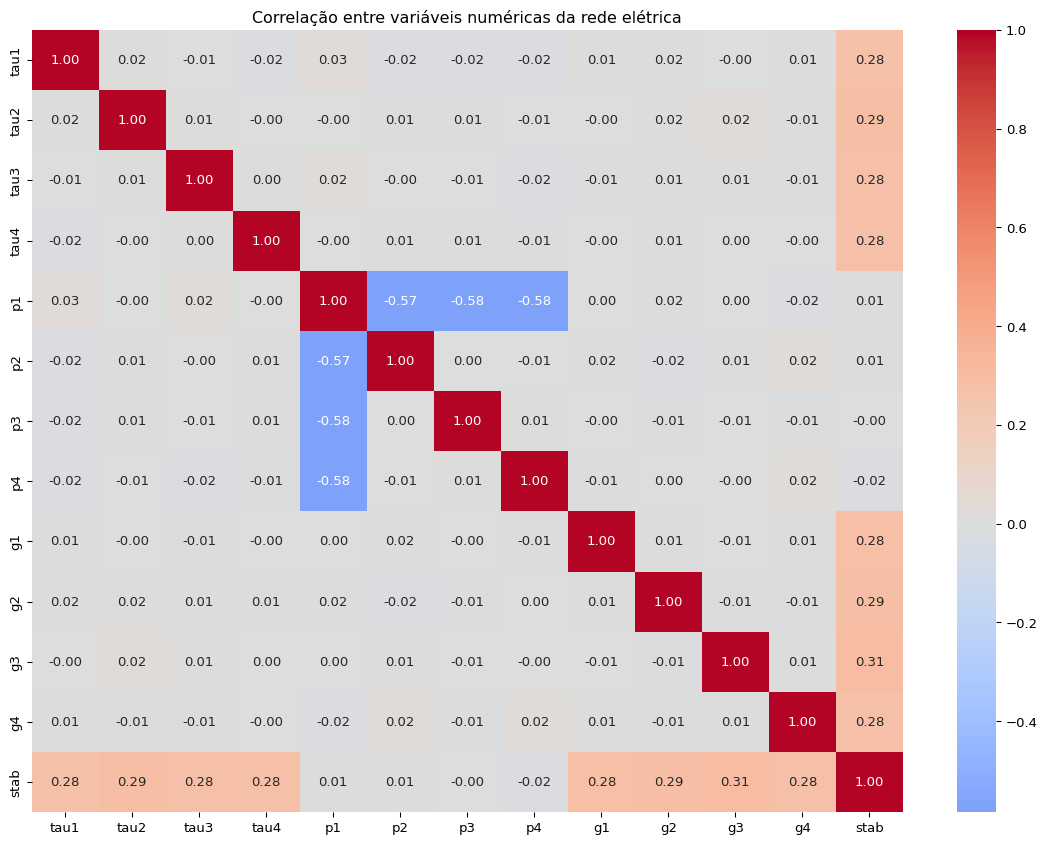

In [ ]:
# Inclui apenas colunas numéricas; stabf é uma classe e não entra na correlação.
matriz_correlacao = df.select_dtypes(include='number').corr()
display(matriz_correlacao)
plt.figure(figsize=(12, 9))
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis numéricas da rede elétrica')
plt.tight_layout()
plt.show()


## 5. Seleção e visualização das variáveis

Selecionamos as cinco maiores correlações absolutas com `stab`, preservamos os sinais na tabela e criamos cinco gráficos de dispersão.


Maior correlação absoluta: g3 (0.3082)


,Posição,Variável,Correlação original com stab
0,1,g3,0.308235
1,2,g2,0.293601
2,3,tau2,0.290975
3,4,g1,0.282774
4,5,tau3,0.280700


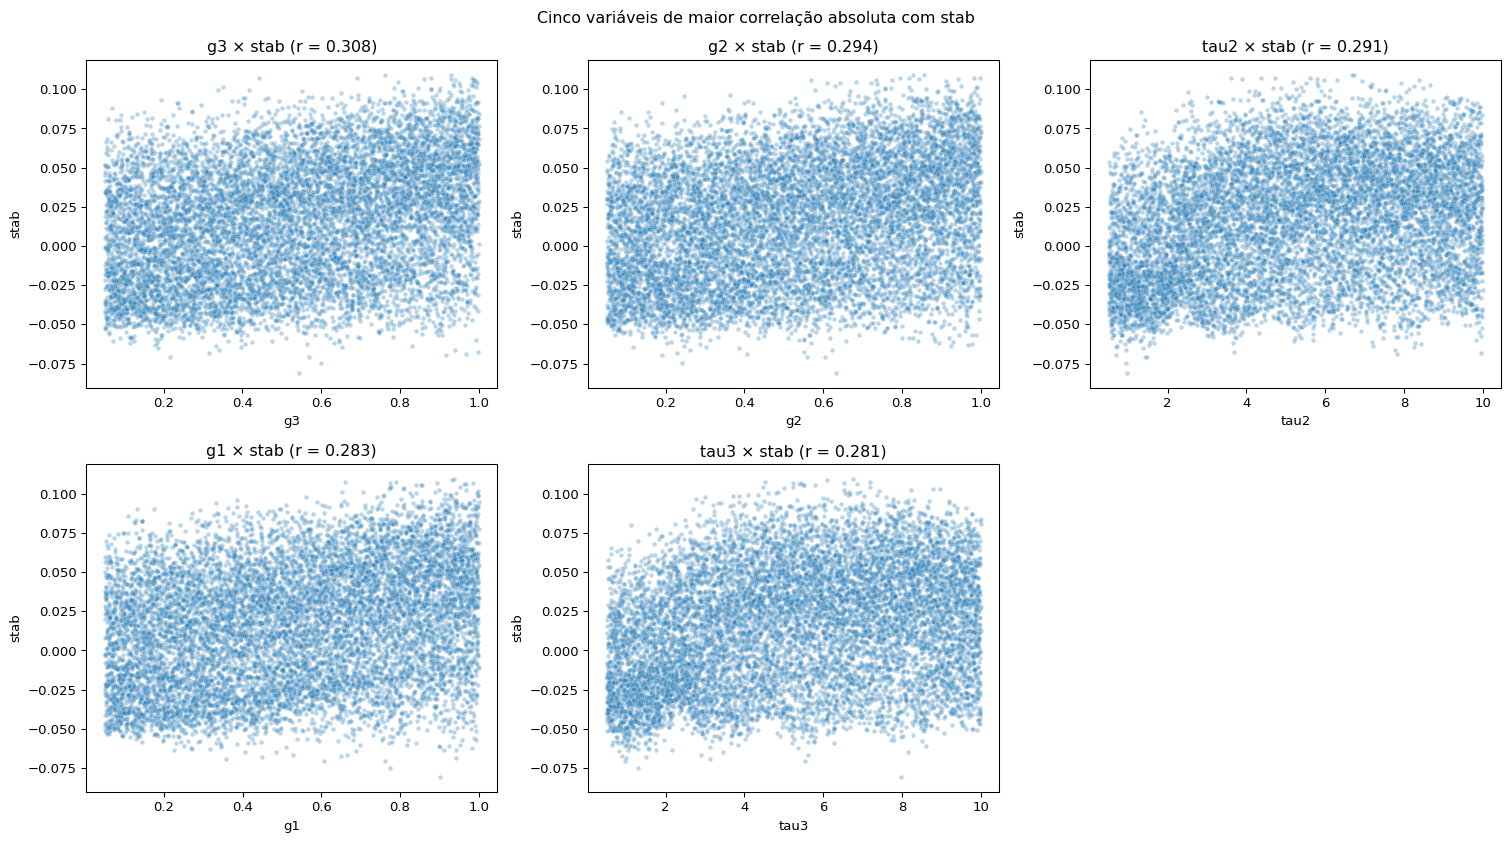

In [ ]:
# Seleção por correlação absoluta, mantendo o sinal original ao apresentar.
correlacoes_stab = matriz_correlacao['stab'].drop('stab').dropna()
cinco_variaveis = correlacoes_stab.abs().nlargest(5).index.tolist()
tabela_correlacoes = pd.DataFrame({
    'Posição': range(1, 6),
    'Variável': cinco_variaveis,
    'Correlação original com stab': correlacoes_stab.loc[cinco_variaveis].values,
})
display(tabela_correlacoes)
print(f'Maior correlação absoluta: {cinco_variaveis[0]} '
      f'({correlacoes_stab[cinco_variaveis[0]]:.4f})')

fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
for eixo, coluna in zip(eixos.flat, cinco_variaveis):
    sns.scatterplot(data=df, x=coluna, y='stab', ax=eixo, s=12, alpha=0.3)
    eixo.set_title(f'{coluna} × stab (r = {correlacoes_stab[coluna]:.3f})')
for eixo in eixos.flat[len(cinco_variaveis):]:
    eixo.axis('off')
fig.suptitle('Cinco variáveis de maior correlação absoluta com stab')
plt.tight_layout()
plt.show()


### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | `g3` | 0,3082 |
| 2 | `g2` | 0,2936 |
| 3 | `tau2` | 0,2910 |
| 4 | `g1` | 0,2828 |
| 5 | `tau3` | 0,2807 |

**Maior correlação absoluta:** `g3` (0,3082).  
**Dispersão:** as cinco relações são positivas, mas os pontos têm bastante dispersão: cada variável isolada explica apenas parte das variações de `stab`.


# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [ ]:
X = df[cinco_variaveis]
display(X.head())
display(y.head())


,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Treino: {len(X_treino)} registros; teste: {len(X_teste)} registros.')


Treino: 8000 registros; teste: 2000 registros.


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [ ]:
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)
y_previsao_1 = modeloLR.predict(X_teste)
print('Primeiras previsões do Modelo 1:', y_previsao_1[:5])


Primeiras previsões do Modelo 1: [ 0.0478946   0.03781055 -0.00143381 -0.03422274  0.01228364]


## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [ ]:
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)
print(f'Modelo 1 — R²: {r2_modelo_1:.6f} | MAE: {mae_modelo_1:.6f} | MSE: {mse_modelo_1:.6f}')


Modelo 1 — R²: 0.401770 | MAE: 0.023310 | MSE: 0.000811


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [ ]:
X_tau_g = df.loc[:, df.columns.str.startswith(('tau', 'g'))]
print('Colunas selecionadas:', X_tau_g.columns.tolist())
display(X_tau_g.head())


Colunas selecionadas: ['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']


,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [ ]:
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(
    X_tau_g, y, test_size=0.2, random_state=42
)
print(f'Treino: {len(X2_treino)} registros; teste: {len(X2_teste)} registros.')
print('Mesmos índices de teste:', y_teste.index.equals(y2_teste.index))


Treino: 8000 registros; teste: 2000 registros.
Mesmos índices de teste: True


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [ ]:
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)
print(f'Modelo 2 — R²: {r2_modelo_2:.6f} | MAE: {mae_modelo_2:.6f} | MSE: {mse_modelo_2:.6f}')


Modelo 2 — R²: 0.645229 | MAE: 0.017553 | MSE: 0.000481


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [ ]:
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Cinco maiores correlações', 'Todas as variáveis tau e g'],
    'Variáveis utilizadas': [', '.join(cinco_variaveis), ', '.join(X_tau_g.columns)],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2],
})
display(comparacao_modelos)


,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Cinco maiores correlações,"g3, g2, tau2, g1, tau3",0.401770,0.023310,0.000811
1,Todas as variáveis tau e g,"tau1, tau2, tau3, tau4, g1, g2, g3, g4",0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

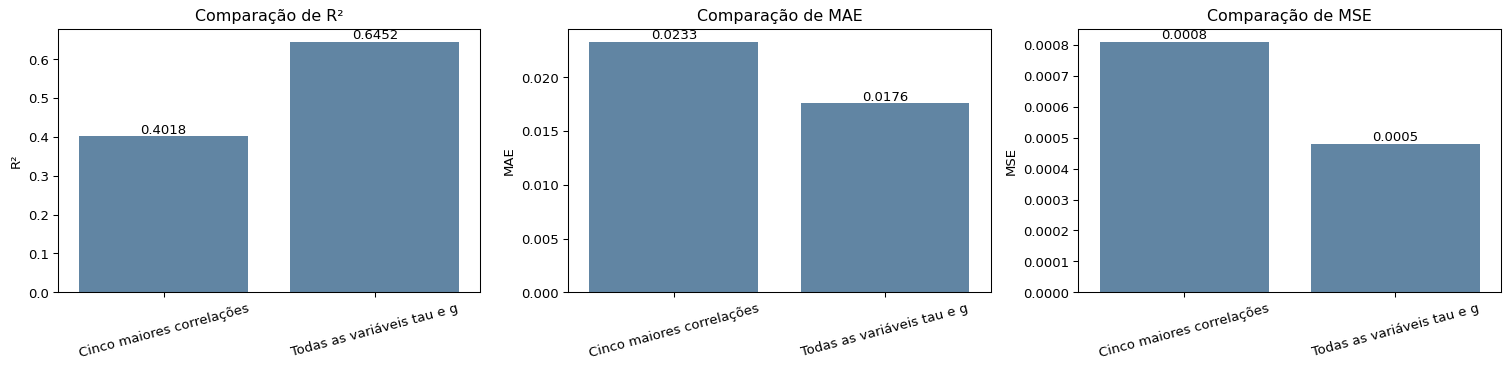

In [ ]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4))
for eixo, metrica in zip(eixos, ('R²', 'MAE', 'MSE')):
    sns.barplot(data=comparacao_modelos, x='Modelo', y=metrica, ax=eixo, color='#5686ae')
    eixo.set_title(f'Comparação de {metrica}')
    eixo.set_xlabel('')
    eixo.tick_params(axis='x', rotation=15)
    for i, valor in enumerate(comparacao_modelos[metrica]):
        eixo.text(i, valor, f'{valor:.4f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


## Análise comparativa final

**1. Maior R²:** Modelo 2 (0,645229) contra Modelo 1 (0,401770).  
**2. Menor MAE:** Modelo 2 (0,017553) contra Modelo 1 (0,023310).  
**3. Menor MSE:** Modelo 2 (0,000481) contra Modelo 1 (0,000811).  
**4. As três métricas concordam?** Sim. O segundo modelo explica mais variação de `stab` e apresenta menores erros médio absoluto e quadrático.  
**5. O que mudou?** Ao usar todas as variáveis `tau` e `g`, o R² sobe de 0,401770 para 0,645229, enquanto MAE cai de 0,023310 para 0,017553 e MSE de 0,000811 para 0,000481.  
**6. Escolha:** o Modelo 2, pelo maior R² e menores MAE e MSE nos mesmos registros de teste.
